In [1]:
# =====================================================
# Multiple Linear Regression - MagicBricks House Price Prediction
# =====================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [4]:
## loading a dataset

df = pd.read_csv('MagicBricks.csv')
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [5]:
print("dataset shape:",df.shape)
df.head()

dataset shape: (1259, 11)


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [6]:
### ------------ 2.Enhanced eda ------------

In [7]:
print("\n=== basic info==")
df.info()


=== basic info==
<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   str    
 4   Locality     1259 non-null   str    
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   str    
 8   Transaction  1259 non-null   str    
 9   Type         1254 non-null   str    
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 225.4 KB


In [8]:
print("\n ==== missing values==")

missing = df.isnull().sum()*100/len(df)
print(missing[missing>0].sort_values(ascending=False))


 ==== missing values==
Per_Sqft      19.142176
Parking        2.621128
Furnishing     0.397141
Type           0.397141
Bathroom       0.158856
dtype: float64


In [9]:
print("\n == descriptive statistics ===")
df.describe()


 == descriptive statistics ===


,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [10]:
### --- univariate analysis --->

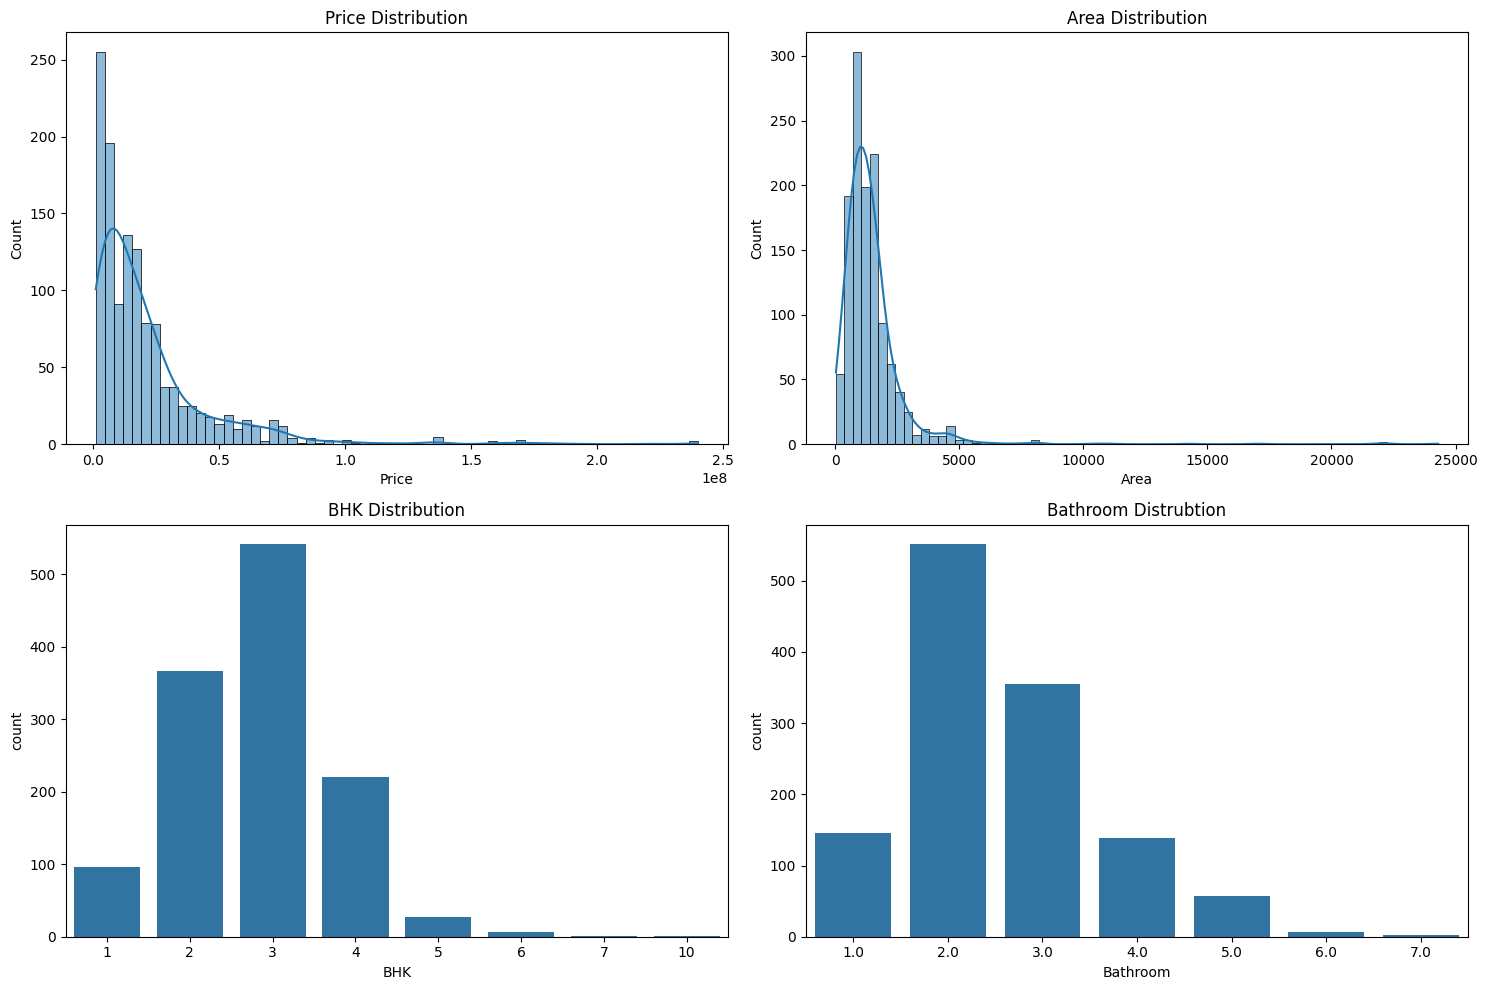

In [11]:
fig,axes = plt.subplots(2,2,figsize=(15,10))

sns.histplot(df['Price'],kde=True,ax=axes[0,0])
axes[0,0].set_title('Price Distribution')

sns.histplot(df['Area'],kde=True,ax=axes[0,1])
axes[0,1].set_title('Area Distribution')

sns.countplot(data=df,x='BHK',ax=axes[1,0])
axes[1,0].set_title('BHK Distribution')

sns.countplot(data=df,x='Bathroom',ax=axes[1,1])
axes[1,1].set_title('Bathroom Distrubtion')

plt.tight_layout()
plt.show()

In [12]:
### bivariate analysis

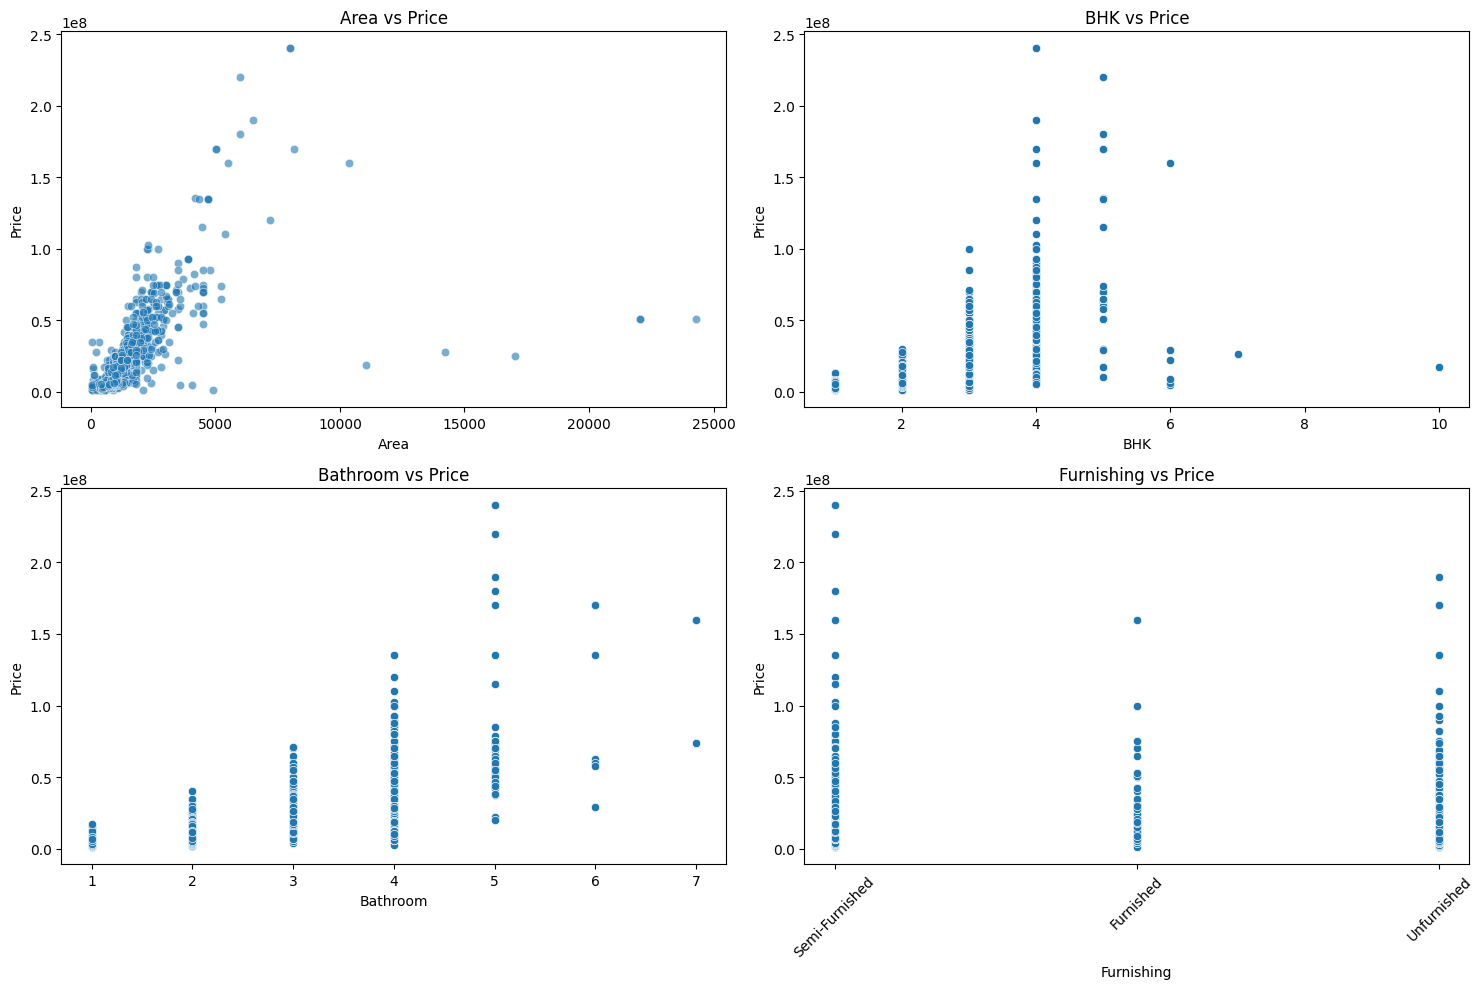

In [13]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.scatterplot(data=df,x='Area',y='Price',alpha=0.6)
plt.title('Area vs Price')

plt.subplot(2,2,2)
sns.scatterplot(data=df,x='BHK',y='Price')
plt.title('BHK vs Price')

plt.subplot(2,2,3)
sns.scatterplot(data=df,x='Bathroom',y='Price')
plt.title('Bathroom vs Price')

plt.subplot(2,2,4)
sns.scatterplot(data=df,x='Furnishing',y='Price')
plt.title('Furnishing vs Price')
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

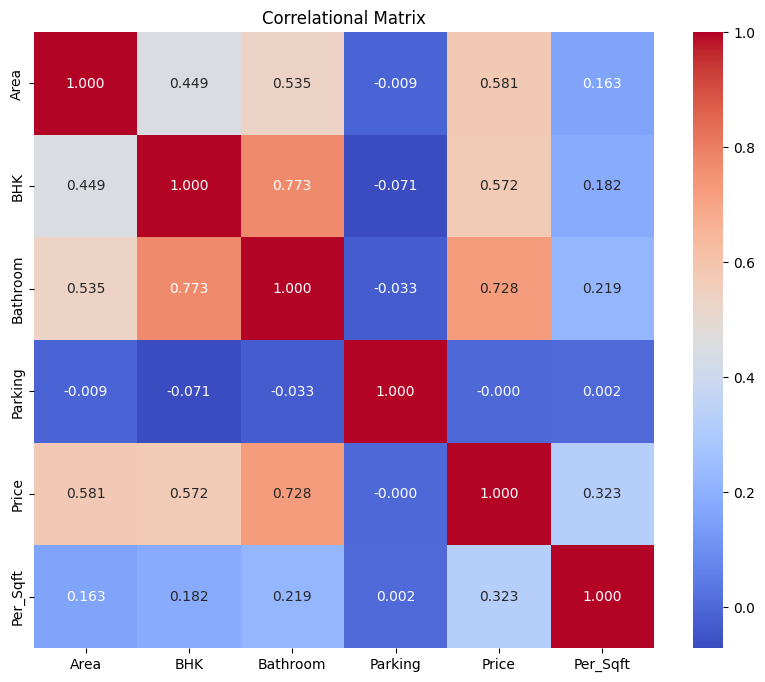

In [14]:
## correlational


numerical_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numerical_df.corr(),annot=True,cmap='coolwarm',fmt='.3f')
plt.title('Correlational Matrix')
plt.show()

In [15]:
#### -----------  enhanced data preprocessing

In [16]:
## create a copy

data = df.copy()

In [17]:
## drop target leakage feature

data = data.drop(columns=['Per_Sqft'])

In [18]:
## handle missing values smartly

print("\n Handling Missing values...")


 Handling Missing values...


In [19]:
## numerical columns -median imputation

data['Bathroom'] = data['Bathroom'].fillna(data['Bathroom'].median())
data['Parking'] = data['Parking'].fillna(data['Parking'].median())

In [20]:
### categorical columns -mode imputation

data['Furnishing']=data['Furnishing'].fillna(data['Furnishing'].mode()[0])
data['Type']=data['Type'].fillna(data['Type'].mode()[0])
data['Status']=data['Status'].fillna(data['Status'].mode()[0])
data['Transaction']=data['Transaction'].fillna(data['Transaction'].mode()[0])

In [21]:
###Outlier Treatment (Important for Linear Regression)
print("Removing Outliers...")

Removing Outliers...


In [22]:
## using IQR method for price and area

def remove_outliers_iqr(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    return df[(df[column]>=lower)&(df[column]<=upper)]

In [23]:
data = remove_outliers_iqr(data,'Price')
data = remove_outliers_iqr(data,'Area')

In [24]:
data

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor
...,...,...,...,...,...,...,...,...,...,...
1252,1800.0,3,3.0,Semi-Furnished,"Nehru Enclave, Kalkaji",1.0,26000000,Ready_to_move,Resale,Builder_Floor
1253,1200.0,3,3.0,Semi-Furnished,Chittaranjan Park,1.0,16500000,Ready_to_move,Resale,Builder_Floor
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor


In [25]:
data['Price']

0        6500000
1        5000000
2       15500000
3        4200000
4        6200000
          ...   
1252    26000000
1253    16500000
1255    12500000
1256    17500000
1257    11500000
Name: Price, Length: 1118, dtype: int64

In [26]:
print(f"shape after outlier removal:{data.shape}")

shape after outlier removal:(1118, 10)


In [27]:
## feature engineering 

data['Price_per_sqft'] = data['Price']/data['Area']  ## derived feautre
data['Total_Rooms']=data['BHK']+data['Bathroom']

In [28]:
data['Total_Rooms']

0       5.0
1       4.0
2       4.0
3       4.0
4       4.0
       ... 
1252    6.0
1253    6.0
1255    5.0
1256    6.0
1257    4.0
Name: Total_Rooms, Length: 1118, dtype: float64

In [29]:
data['Price_per_sqft']

0        8125.000000
1        6666.666667
2       16315.789474
3        7000.000000
4        9538.461538
            ...     
1252    14444.444444
1253    13750.000000
1255    11904.761905
1256    20000.000000
1257    11616.161616
Name: Price_per_sqft, Length: 1118, dtype: float64

In [30]:
## final feature selection

features = ['Area','BHK','Bathroom','Parking','Furnishing','Status','Transaction','Type']

In [31]:
x = data[features]
y = data['Price']

In [32]:
## one-hot encoding

x = pd.get_dummies(x,columns=['Furnishing','Status','Transaction','Type'],drop_first=True)

In [33]:
print(f"Final Feature Count after Encoding: {x.shape[1]}")

Final Feature Count after Encoding: 9


In [34]:
## train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42)

In [35]:
## model training
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
## model evaluation

y_pred = model.predict(X_test)

In [37]:
y_pred

array([ 3.11010524e+07,  2.54335370e+07,  3.56525606e+07,  4.49878151e+06,
        5.97240175e+06,  5.47156990e+06,  9.27429826e+06,  6.66098707e+06,
        1.11131818e+07,  2.48064204e+07,  1.60308436e+07,  8.14420689e+06,
        1.44775062e+07,  1.85341363e+07,  3.05446445e+07,  5.42133439e+06,
        3.50525931e+07,  7.92698892e+06,  8.38475141e+05,  8.70322613e+06,
        2.17740455e+07,  2.33882130e+07,  1.21282901e+07,  1.11721271e+07,
        2.60328779e+06,  1.50918297e+06,  2.04283728e+07,  1.14325739e+07,
        6.06769122e+06,  1.65443297e+07,  3.02725574e+07,  1.16224012e+07,
        6.20542976e+06,  6.51453931e+06,  9.29221251e+06,  1.38641191e+07,
        1.99583689e+07,  9.35939031e+06,  6.73627177e+06,  1.79651017e+07,
        1.92090713e+07,  1.17515400e+06,  2.64869034e+07,  9.29221251e+06,
        9.97126552e+06,  1.08754470e+07,  2.56359680e+06,  1.96142824e+05,
        2.06654090e+07,  1.72307786e+07,  7.12641452e+06,  1.19721759e+07,
       -2.92171758e+05,  

In [38]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("\n"+"="*60)
print("Multiple Linear Regression performance")
print("="*60)
print(f"Mean absolute error :₹{mae:,.0f}")
print(f"Root mean square error(rmse):₹{rmse:,.0f}")
print(f"r2 score: {r2:.4f} ({r2*100:.2f}%)")


Multiple Linear Regression performance
Mean absolute error :₹4,846,311
Root mean square error(rmse):₹6,377,844
r2 score: 0.6678 (66.78%)


In [39]:
## feautre importance -----

coef_df = pd.DataFrame({
    'Feature':x.columns,
    'Coefficient':model.coef_
    
}).sort_values(by='Coefficient',ascending=False)

print("\n top 10 most important features:")
print(coef_df.head(10))


 top 10 most important features:
                     Feature   Coefficient
2                   Bathroom  4.562818e+06
8         Type_Builder_Floor  6.118752e+05
4  Furnishing_Semi-Furnished  2.037565e+05
0                       Area  1.334291e+04
3                    Parking  1.138208e+04
5     Furnishing_Unfurnished -2.263526e+05
7         Transaction_Resale -6.243047e+05
6       Status_Ready_to_move -1.258604e+06
1                        BHK -1.401468e+06


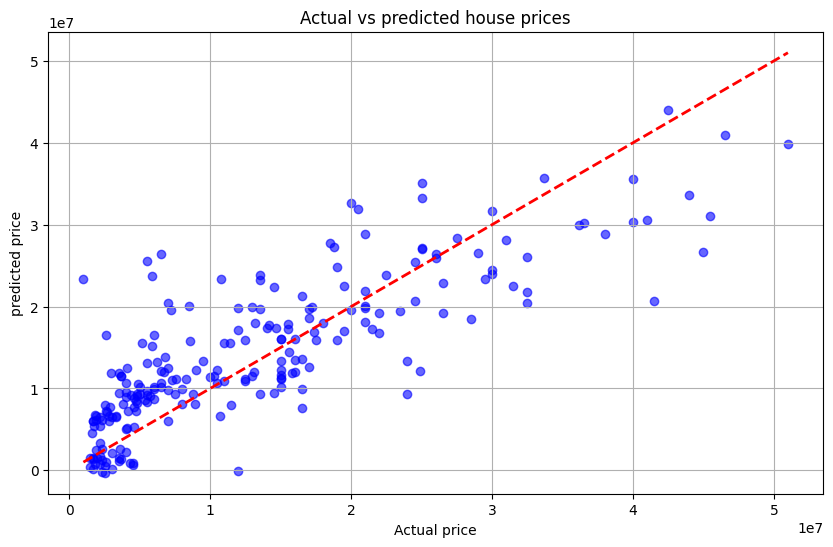

In [40]:
## actual vs predicted plot

plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred,alpha=0.6,color='blue')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
plt.xlabel('Actual price')
plt.ylabel('predicted price')
plt.title('Actual vs predicted house prices')
plt.grid(True)
plt.show()

In [41]:
## prediction function

def predict_price(area=1200, bhk=3, bathroom=3, parking=2, 
                  furnishing='Semi-Furnished', status='Ready_to_move', 
                  transaction='New_Property', house_type='Builder_Floor'):
    
    input_data = pd.DataFrame({
        'Area': [area],
        'BHK': [bhk],
        'Bathroom': [bathroom],
        'Parking': [parking],
        'Total_Rooms': [bhk + bathroom],
        'Area_per_Room': [area / (bhk + bathroom + 1)],
        'Furnishing': [furnishing],
        'Status': [status],
        'Transaction': [transaction],
        'Type': [house_type]
    })
    
    input_encoded = pd.get_dummies(input_data, columns=['Furnishing','Status','Transaction','Type'], drop_first=True)
    input_encoded = input_encoded.reindex(columns=x.columns, fill_value=0)
    
    predicted_price = model.predict(input_encoded)[0]
    print(f"\nPredicted House Price: ₹{predicted_price:,.0f}")


In [42]:
# Test the function
predict_price(1100, 3, 3, 2, 'Semi-Furnished', 'Ready_to_move', 'New_Property', 'Builder_Floor')


Predicted House Price: ₹18,214,146


In [43]:
import pickle

# After training the model
with open('house_price_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# Also save the feature columns (very important)
with open('feature_columns.pkl', 'wb') as file:
    pickle.dump(x.columns.tolist(), file)

print("✅ Model and features saved successfully!")

✅ Model and features saved successfully!
